In [1]:
!pip install --quiet scikit-learn

In [2]:
%cd ..

/Users/danorel/Workspace/Education/University/NYU/Research/xeda


In [3]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())

True

In [4]:
import random
import chromadb
import copy
import json
import typing as t
import pandas as pd
import numpy as np
import uuid
import pathlib
import s3fs

from chromadb.utils import embedding_functions
from dagster import EnvVar
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

from pipeline.resources import S3FSResource
from pipeline.solid.pipeline_annotator import annotate_pipeline
from pipeline.solid.utils.model_manager import ModelManager
from pipeline.solid.utils.pipelines.pipeline_precalculated_sets import PipelineWithPrecalculatedSets
from typings.pipeline import OperatorRequestData


from constants import (
    AWS_ACCESS_KEY_ID,
    AWS_SECRET_ACCESS_KEY,
    AWS_S3_ENDPOINT_URL,
    AWS_S3_REGION_NAME,
    AWS_S3_BUCKET_NAME,
    AWS_S3_USE_SSL,
    GROUPS_CSV_PATH,
    OPENAI_API_KEY,
    VECTOR_STORE_COLLECTION,
    VECTOR_STORE_HOST,
    VECTOR_STORE_PORT,
    UNIVERSAL_POLICY_NAME
)
from typings.pipeline import Pipeline
from pipeline.solid.pipeline_sampler import next_pipeline_iter
from utils.s3 import pull_keras_model

2024-04-19 12:36:52.581616: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
pretrained_embeddings = embedding_functions.OpenAIEmbeddingFunction(
    api_key=OPENAI_API_KEY,
    model_name="text-embedding-ada-002"
)

vector_store = chromadb.HttpClient(
    host=VECTOR_STORE_HOST, 
    port=VECTOR_STORE_PORT
)

In [6]:
vector_collection = vector_store.get_collection(VECTOR_STORE_COLLECTION)

In [7]:
fs = s3fs.S3FileSystem(
    key=AWS_ACCESS_KEY_ID,
    secret=AWS_SECRET_ACCESS_KEY,
    endpoint_url=AWS_S3_ENDPOINT_URL,
    use_ssl=AWS_S3_USE_SSL,
    client_kwargs={"region_name": AWS_S3_REGION_NAME},
)

In [8]:
database_pipeline_cache = {}
database_pipeline_cache["galaxies"] = PipelineWithPrecalculatedSets(
    "sdss",
    ["galaxies"],
    discrete_categories_count=10,
    min_set_size=10,
    exploration_columns=[
        "galaxies.u",
        "galaxies.g",
        "galaxies.r",
        "galaxies.i",
        "galaxies.z",
        "galaxies.petroRad_r",
        "galaxies.redshift",
    ],
    id_column="galaxies.objID",
)

In [9]:
model_manager = ModelManager(database_pipeline_cache["galaxies"], models = {
    "set": pull_keras_model(
        s3fs=fs,
        bucket_name=AWS_S3_BUCKET_NAME,
        policy_name=UNIVERSAL_POLICY_NAME,
        model_name="set_actor",
    ),
    "operation": pull_keras_model(
        s3fs=fs,
        bucket_name=AWS_S3_BUCKET_NAME,
        policy_name=UNIVERSAL_POLICY_NAME,
        model_name="operation_actor",
    ),
    "set_op_counters": None,
})

In [10]:
groups_df = pd.read_csv(GROUPS_CSV_PATH)

In [11]:
annotated_pipelines = []
for annotated_file in fs.glob('annotated_pipelines/*.json'):
    with annotated_file.open('r') as f:
        annotated_pipelines.append(json.load(f))

In [12]:
for annotated_pipeline in annotated_pipelines:
    (
        pipeline_ids,
        pipeline_documents,
        pipeline_sentences
    ) = pipeline_to_embedding(annotated_pipeline)
    vector_collection.add(
        ids=pipeline_ids,
        documents=pipeline_documents,
        embeddings=pretrained_embeddings(pipeline_sentences),
    )

In [13]:
pipeline_collection = vector_collection.get()

In [14]:
def node_to_encoding(node, only_annotation = True):
    if only_annotation:
        annotation = node.get('annotation')
    else:
        annotation = node
    if annotation == None:
        return ''
    node_encoding = []
    for k, v in annotation.items():
        if isinstance(v, dict):
            for key in v:
                node_encoding.append(f"{k}_{key} = {v[key]}")
        else:
            node_encoding.append(f"{k} = {v}")
    return ', '.join(node_encoding)


def pipeline_to_splits(pipeline: Pipeline) -> t.List[Pipeline]:
    splits = []
    pipeline_encoding = []
    for node in reversed(pipeline):
        node_encoding = node_to_encoding(node)
        pipeline_encoding.append(node_encoding)
        splits.append(copy.deepcopy(pipeline_encoding))
    return splits


def pipeline_to_embedding(pipeline: Pipeline):
    pipeline_splits = pipeline_to_splits(pipeline)
    pipeline_payload = (
        [str(uuid.uuid4()) for _ in range(len(pipeline_splits))],
        [json.dumps(copy.deepcopy(pipeline)) for _ in range(len(pipeline_splits))],
        [';'.join(pipeline_split) for pipeline_split in pipeline_splits]
    )
    return pipeline_payload

In [15]:
def select_attributes(pipeline: Pipeline):
    return f"{[node['operator'] for node in pipeline]}"


def explore_pipeline(partial_pipeline: Pipeline, database_pipeline_cache, k: int):
    # This is a stub to simulate pipeline exploration.
    # In a real scenario, this would involve applying transformations or decisions based on an RL model.

    partial_latest_node = partial_pipeline[-1]
    partial_latest_request_data = partial_latest_node.get("requestData")
    
    terminal_request_data = OperatorRequestData(**partial_latest_request_data)
    terminal_pipeline = partial_pipeline.copy()
    
    for i in range(len(partial_pipeline), len(partial_pipeline) + k):
        try:
            terminal_node, terminal_request_data = next_pipeline_iter(
                database_pipeline_cache,
                model_manager,
                terminal_request_data
            )
            terminal_pipeline.append(terminal_node)
        except ValueError:
            print(f"Unexpectedly exited from pipeline generation on step {i}. Saving pipeline as it is...")
            break
    
    return annotate_pipeline(groups_df, terminal_pipeline)


def make_experiment(pipeline_index: int, type_of_similarity: str, k: int, verbose: bool = False):
    ids  = pipeline_collection['ids']
    docs = pipeline_collection['documents']

    partial_pipeline_id   = ids[pipeline_index]
    partial_pipeline = json.loads(docs[pipeline_index])
    
    rest_pipeline_ids = ids[:pipeline_index] + ids[pipeline_index+1:]
    rest_pipelines = [json.loads(doc) for doc in docs[:pipeline_index] + docs[pipeline_index+1:]]
    
    (
        partial_pipeline_ids,
        partial_pipeline_documents,
        partial_pipeline_sentences
    ) = pipeline_to_embedding(partial_pipeline)
    
    partial_annotation_embedding = pretrained_embeddings(partial_pipeline_sentences)
    partial_response = vector_collection.query(
        query_embeddings=partial_annotation_embedding,
        n_results=len(rest_pipeline_ids),
        include=["distances", "documents"]
    )
    
    terminal_pipeline = explore_pipeline(partial_pipeline, database_pipeline_cache, k=k)
    (
        terminal_pipeline_ids,
        terminal_pipeline_documents,
        terminal_pipeline_sentences
    ) = pipeline_to_embedding(terminal_pipeline)
    terminal_annotation_embedding = pretrained_embeddings(terminal_pipeline_sentences)
    
    if verbose:
        print(f"Terminal pipeline: {select_attributes(terminal_pipeline)}\n")

    partial_explanation_pipelines = partial_response['documents'][0]

    min_explanation_pipeline, max_explanation_pipeline = (
        json.loads(partial_explanation_pipelines[0]),
        json.loads(partial_explanation_pipelines[-1])
    )

    if verbose:
        print(f"Min pipeline: {min_explanation_distance}%, {select_attributes(min_explanation_pipeline)}")
        print(f"Max pipeline: {max_explanation_distance}%, {select_attributes(max_explanation_pipeline)}\n")

    (
        min_pipeline_ids,
        min_pipeline_documents,
        min_pipeline_sentences
    ) = pipeline_to_embedding(min_explanation_pipeline)
    min_annotation_embedding = pretrained_embeddings(min_pipeline_sentences)

    (
        max_pipeline_ids,
        max_pipeline_documents,
        max_pipeline_sentences
    ) = pipeline_to_embedding(max_explanation_pipeline)
    max_annotation_embedding = pretrained_embeddings(max_pipeline_sentences)

    terminal_annotation_embedding = np.array(terminal_annotation_embedding).mean(axis=0)
    min_annotation_embedding = np.array(min_annotation_embedding).mean(axis=0)
    max_annotation_embedding = np.array(max_annotation_embedding).mean(axis=0)
    
    if type_of_similarity == 'cosine':
        min_to_terminal_similarity = np.dot(terminal_annotation_embedding, min_annotation_embedding)/(np.linalg.norm(terminal_annotation_embedding)*np.linalg.norm(min_annotation_embedding))
        max_to_terminal_similarity = np.dot(terminal_annotation_embedding, max_annotation_embedding)/(np.linalg.norm(terminal_annotation_embedding)*np.linalg.norm(max_annotation_embedding))
    elif type_of_similarity == 'euclidian':
        min_to_terminal_similarity = np.linalg.norm(terminal_annotation_embedding - min_annotation_embedding)
        max_to_terminal_similarity = np.linalg.norm(terminal_annotation_embedding - max_annotation_embedding)
    elif type_of_similarity == 'manhattan':
        min_to_terminal_similarity = np.abs(terminal_annotation_embedding - min_annotation_embedding).sum()
        max_to_terminal_similarity = np.abs(terminal_annotation_embedding - max_annotation_embedding).sum()
    else:
        raise NotImplementedError("Unknown type of similarity")
    
    return {
        "partial_pipeline_id": partial_pipeline_id,
        "min_to_terminal_similarity": min_to_terminal_similarity,
        "max_to_terminal_similarity": max_to_terminal_similarity,
    }

def run_experiments(n: int = 1000, types_of_similarity: list = ['cosine'], exploration_steps: tuple = (3, 6)):
    measurements = pd.DataFrame()
    used_pipeline_ids = set()

    for experiment in tqdm(range(n)):

        print(f"Starting '{experiment + 1}' experiment")

        for k in range(*exploration_steps):

            print(f"Starting a measurement with '{k}' exploration steps")

            for type_of_similarity in types_of_similarity:

                print(f"Starting a measurement with '{type_of_similarity}' type of similarity")
    
                trial = 0
                target_pipeline_index, target_pipeline_id = None, None
                while (target_pipeline_id not in used_pipeline_ids):
                    trial += 1
                    print(f"Making {trial} trial to sample partial pipeline within not seen pipelines")
                    (
                        target_pipeline_index,
                        target_pipeline_id
                    ) = random.sample(list(enumerate(pipeline_collection['ids'])), k=1)[0]
                    if target_pipeline_id is not None:
                        used_pipeline_ids.add(target_pipeline_id)
                
                measurements = pd.concat([
                    measurements,
                    pd.DataFrame([{
                        "experiment": experiment + 1,
                        "k": k,
                        "type_of_similarity": type_of_similarity,
                        **make_experiment(
                            target_pipeline_index, 
                            type_of_similarity,
                            k, 
                            verbose=False
                        )
                    }])
                ])
        
                print(f"Recored a measurement for {experiment + 1}-th sample {target_pipeline_id}")

    return measurements

In [16]:
if pathlib.Path('experiments.csv'):
    experiments_df = pd.read_csv('visualization.csv')
else:
    experiments_df = run_experiments(
        n=50,
        types_of_similarity=['manhattan', 'cosine', 'euclidian'],
        exploration_steps=(3, 6),
    )

### Visualizations

In [17]:
!pip install --quiet matplotlib seaborn

In [18]:
import matplotlib.pyplot as plt
import math
import seaborn as sns

In [19]:
visualization_df = experiments_df.copy()

In [20]:
visualization_df

,experiment,k,type_of_similarity,partial_pipeline_id,min_to_terminal_similarity,max_to_terminal_similarity
0,1,3,manhattan,5ae3bd07-b37a-46ab-b0e1-cc0e4c9d373c,7.327087,7.725554
1,1,3,cosine,f23f0801-5147-495b-97bc-89989e770143,0.984627,0.953968
2,1,3,euclidian,3c4d2a8f-e970-4dae-b22f-93e42e327787,0.288044,0.285160
3,1,4,manhattan,c11c4095-84b3-4ac7-aff6-2ecb9826910a,6.950720,7.966908
4,1,4,cosine,3b90e110-32c5-4f29-8a0a-9d525621cd76,0.950633,0.974942
...,...,...,...,...,...,...
445,50,4,cosine,3958f553-5419-4104-a318-964489516e53,0.964478,0.956394
446,50,4,euclidian,eb397166-4358-42be-9ca3-29461642e3b6,0.207536,0.303541
447,50,5,manhattan,3958f553-5419-4104-a318-964489516e53,5.845199,7.993009
448,50,5,cosine,89024319-8e7d-40b9-a95d-b298076fcb06,0.987344,0.950653


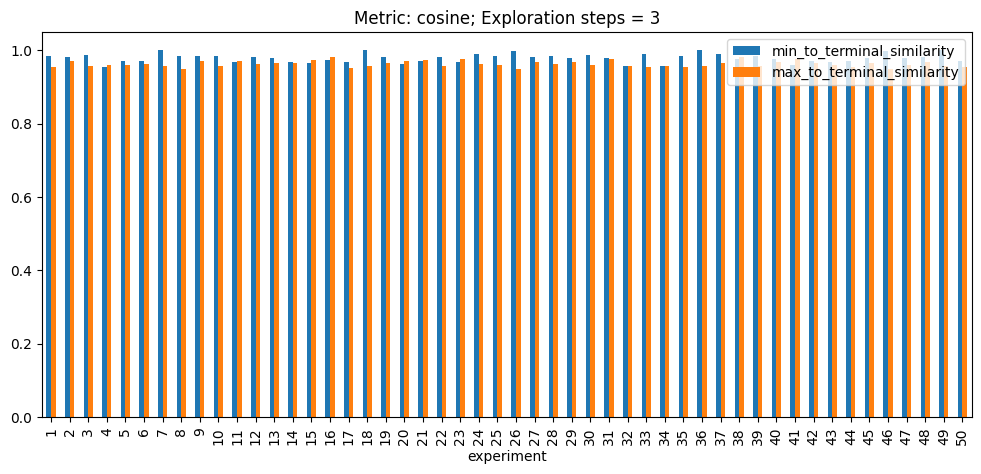

In [21]:
cosine_3k_df = visualization_df.loc[(visualization_df['type_of_similarity'] == 'cosine') & (visualization_df['k'] == 3)][['experiment', 'min_to_terminal_similarity', 'max_to_terminal_similarity']]

plot = cosine_3k_df.plot(
    kind='bar',
    x='experiment', 
    y=['min_to_terminal_similarity', 'max_to_terminal_similarity'],
    title='Metric: cosine; Exploration steps = 3',
    figsize=(12, 5)
)
plt.show()

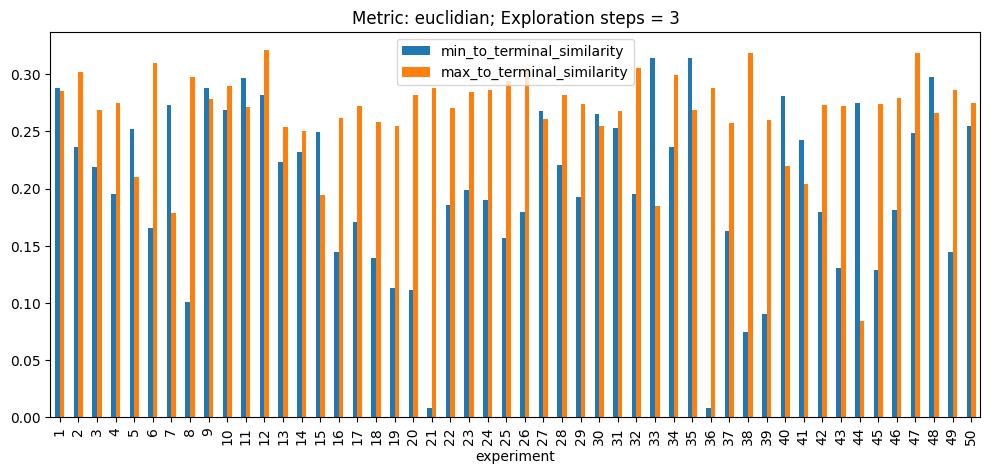

In [22]:
euclidian_3k_df = visualization_df.loc[
    (visualization_df['type_of_similarity'] == 'euclidian') & 
    (visualization_df['k'] == 3)
][['experiment', 'min_to_terminal_similarity', 'max_to_terminal_similarity']]

plot = euclidian_3k_df.plot(
    kind='bar', 
    x='experiment', 
    y=['min_to_terminal_similarity', 'max_to_terminal_similarity'],
    title='Metric: euclidian; Exploration steps = 3',
    figsize=(12, 5)
)
plt.show()

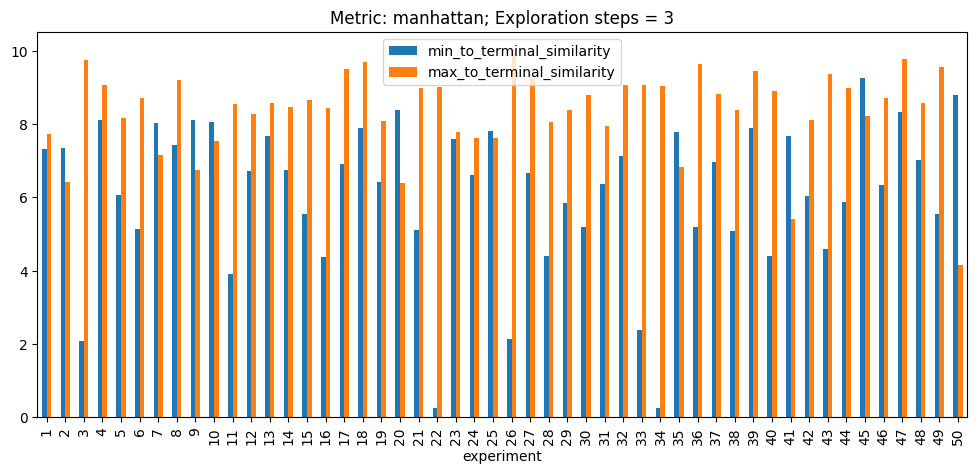

In [23]:
manhattan_3k_df = visualization_df.loc[
    (visualization_df['type_of_similarity'] == 'manhattan') & 
    (visualization_df['k'] == 3)
][['experiment', 'min_to_terminal_similarity', 'max_to_terminal_similarity']]

plot = manhattan_3k_df.plot(
    kind='bar', 
    x='experiment', 
    y=['min_to_terminal_similarity', 'max_to_terminal_similarity'],
    title='Metric: manhattan; Exploration steps = 3',
    figsize=(12, 5)
)
plt.show()

In [24]:
euclidian_df = visualization_df.loc[visualization_df['type_of_similarity'] == 'euclidian']

euclidian_experiments_success_condition = (euclidian_df['max_to_terminal_similarity'] < euclidian_df['min_to_terminal_similarity'])
euclidian_experiments_success_amount = len(euclidian_df.loc[euclidian_experiments_success_condition].values) / len(set(euclidian_df['k'].values))
euclidian_success_rate = euclidian_experiments_success_amount / len(set(euclidian_df['experiment'].values)) * 100

In [25]:
print(f"Success rate: {round(euclidian_success_rate, 2)}%")

Success rate: 26.67%


In [26]:
cosine_df = visualization_df.loc[visualization_df['type_of_similarity'] == 'cosine']

cosine_experiments_success_condition = (cosine_df['max_to_terminal_similarity'] < cosine_df['min_to_terminal_similarity'])
cosine_experiments_success_amount = len(cosine_df.loc[cosine_experiments_success_condition].values) / len(set(cosine_df['k'].values))
cosine_success_rate = cosine_experiments_success_amount / len(set(cosine_df['experiment'].values)) * 100

In [27]:
print(f'Success rate: {round(cosine_success_rate, 2)}%')

Success rate: 71.33%


In [28]:
manhattan_df = visualization_df.loc[visualization_df['type_of_similarity'] == 'manhattan']

manhattan_experiments_success_condition = (manhattan_df['max_to_terminal_similarity'] < manhattan_df['min_to_terminal_similarity'])
manhattan_experiments_success_amount = len(manhattan_df.loc[manhattan_experiments_success_condition].values) / len(set(manhattan_df['k'].values))
manhattan_success_rate = manhattan_experiments_success_amount / len(set(manhattan_df['experiment'].values)) * 100

In [29]:
print(f'Success rate: {round(manhattan_success_rate, 2)}%')

Success rate: 17.33%


In [30]:
mean_success_rate = (manhattan_success_rate + cosine_success_rate + euclidian_success_rate) / 3
print(f'Average success rate: {round(mean_success_rate, 2)}%')

Average success rate: 38.44%


In [31]:
visualization_df.to_csv('visualization.csv', index=False)

### Combine plots

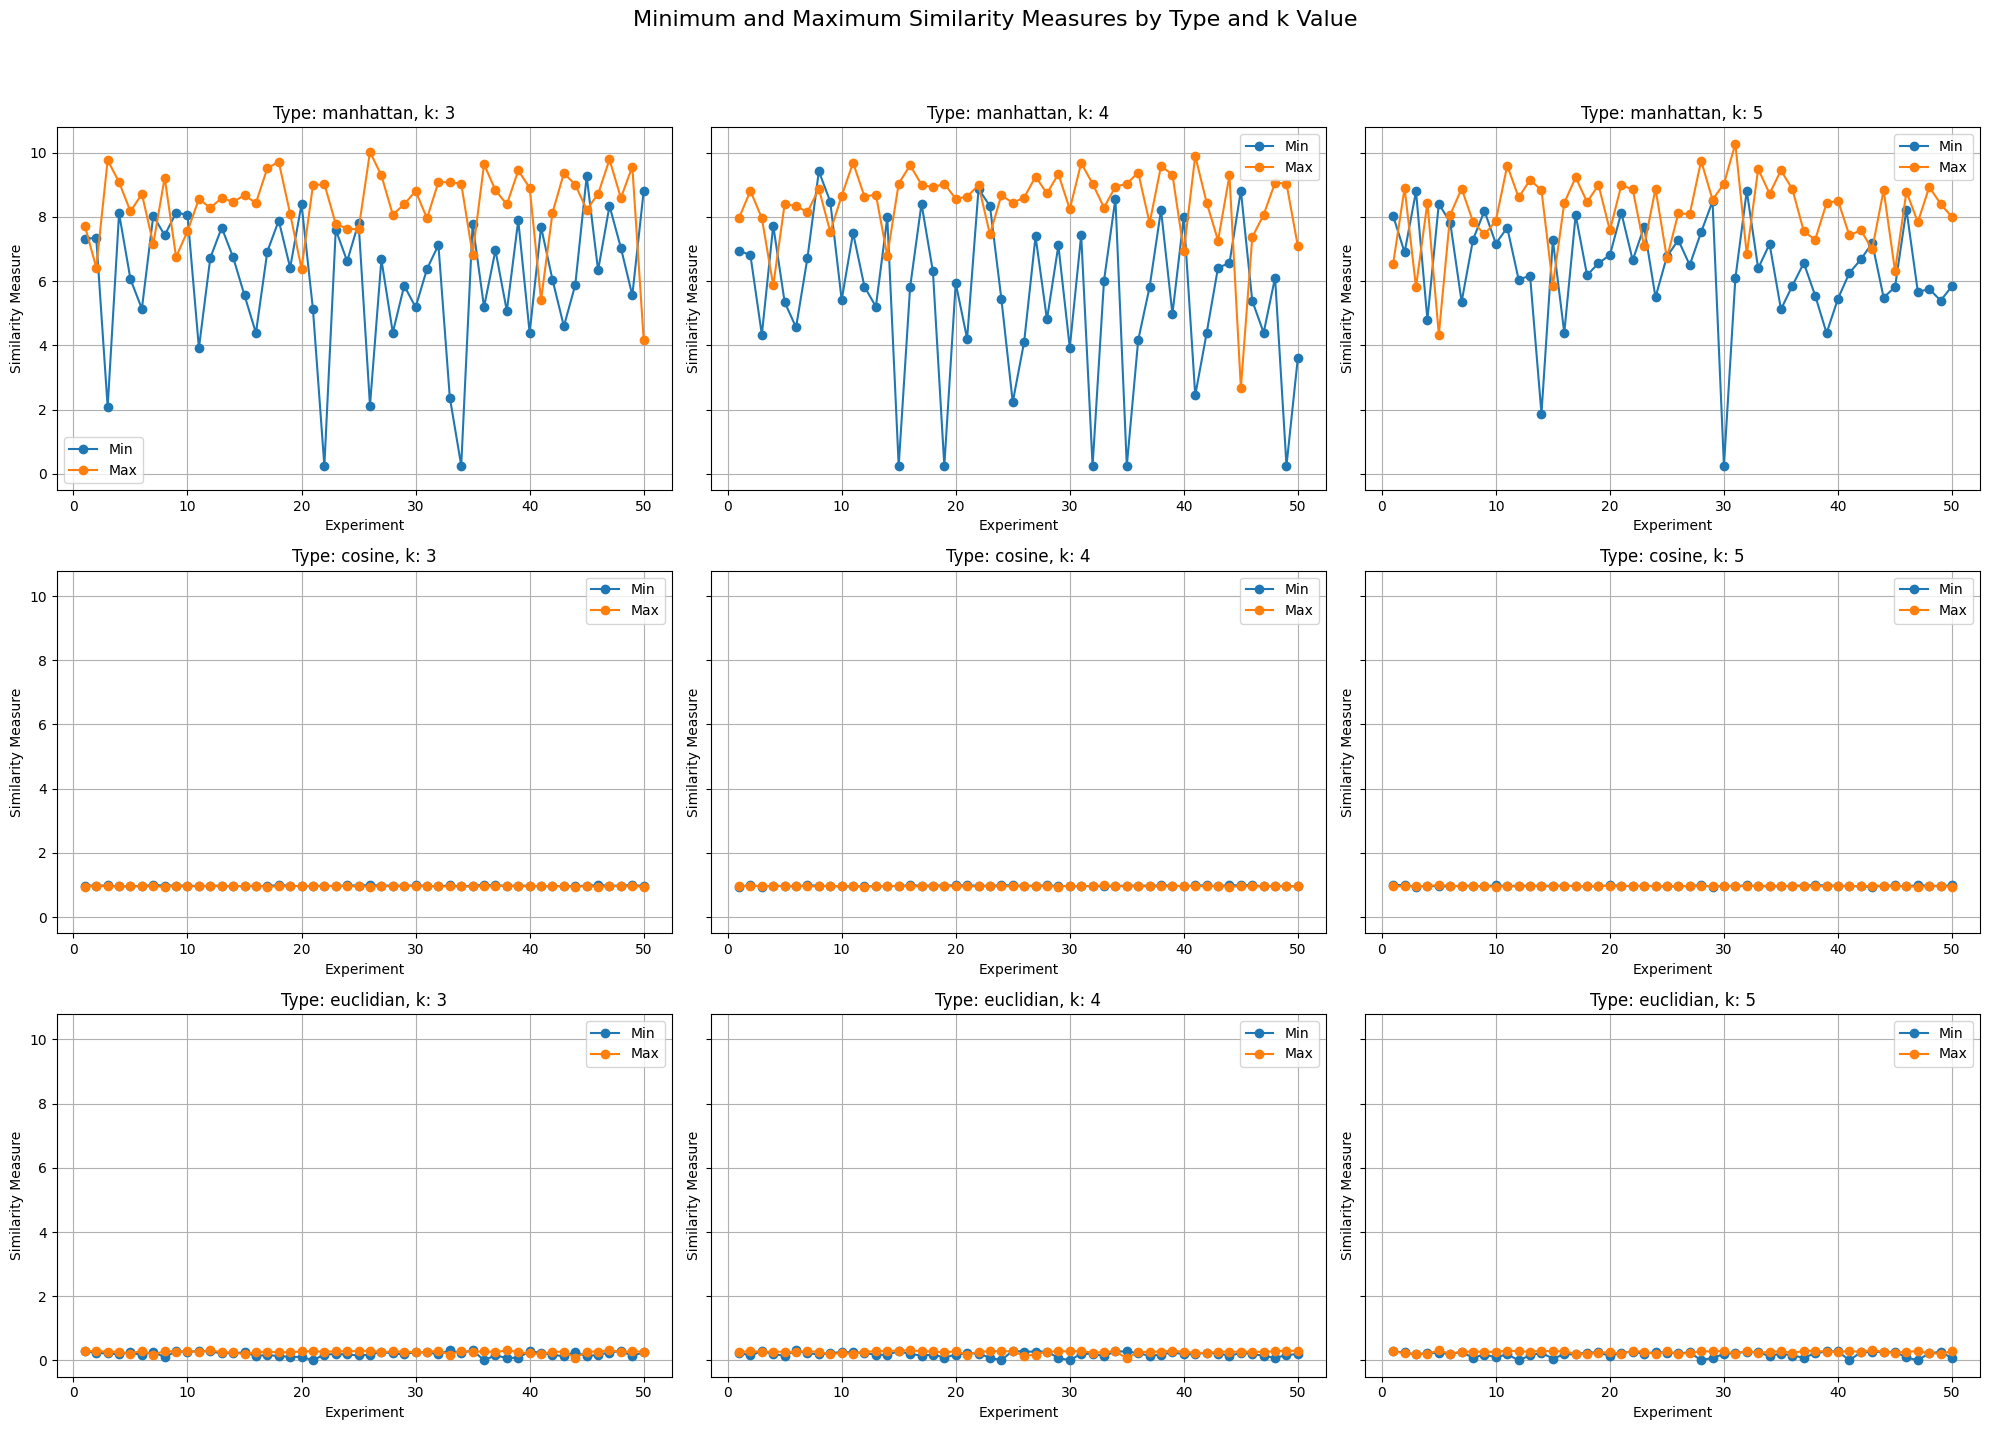

In [37]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15), sharey=True)
fig.suptitle('Minimum and Maximum Similarity Measures by Type and k Value', fontsize=16)

# Unique types of similarity and k values
types_of_similarity = visualization_df['type_of_similarity'].unique()
k_values = visualization_df['k'].unique()

# Plotting loop
for i, sim_type in enumerate(types_of_similarity):
    for j, k_val in enumerate(k_values):
        # Filter data for each type and k value
        subset_data = visualization_df[(visualization_df['type_of_similarity'] == sim_type) & (visualization_df['k'] == k_val)]
        
        if not subset_data.empty:
            ax = axes[i][j]
            ax.plot(subset_data['experiment'], subset_data['min_to_terminal_similarity'], label='Min', marker='o')
            ax.plot(subset_data['experiment'], subset_data['max_to_terminal_similarity'], label='Max', marker='o')
            ax.set_title(f'Type: {sim_type}, k: {k_val}')
            ax.set_xlabel('Experiment')
            ax.set_ylabel('Similarity Measure')
            ax.legend()
            ax.grid(True)
        else:
            axes[i][j].axis('off')

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Analysis

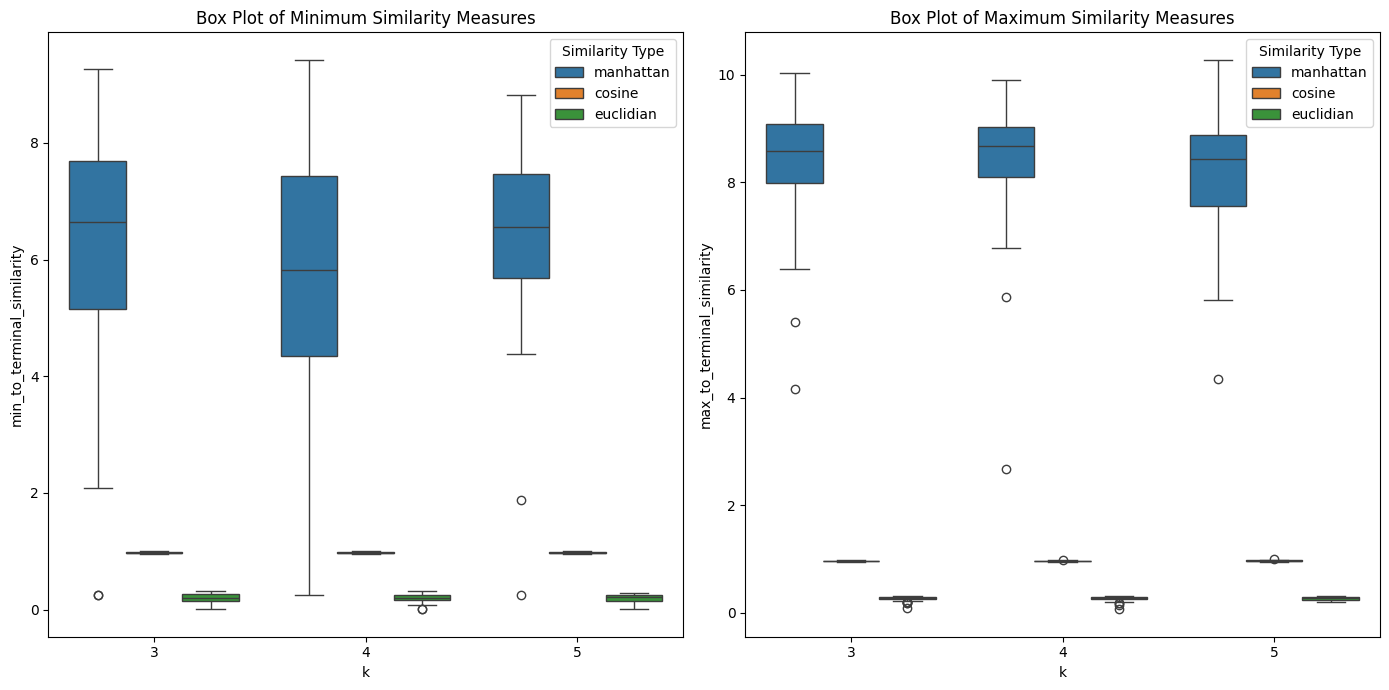

In [42]:
descriptive_stats = experiments_df.groupby(['type_of_similarity', 'k']).agg(
    mean_min=pd.NamedAgg(column='min_to_terminal_similarity', aggfunc='mean'),
    std_min=pd.NamedAgg(column='min_to_terminal_similarity', aggfunc='std'),
    mean_max=pd.NamedAgg(column='max_to_terminal_similarity', aggfunc='mean'),
    std_max=pd.NamedAgg(column='max_to_terminal_similarity', aggfunc='std')
).reset_index()

# Plotting box plots for minimum and maximum similarity measures for each type of similarity and k value
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.boxplot(x='k', y='min_to_terminal_similarity', hue='type_of_similarity', data=experiments_df)
plt.title('Box Plot of Minimum Similarity Measures')
plt.legend(title='Similarity Type')

plt.subplot(1, 2, 2)
sns.boxplot(x='k', y='max_to_terminal_similarity', hue='type_of_similarity', data=experiments_df)
plt.title('Box Plot of Maximum Similarity Measures')
plt.legend(title='Similarity Type')

plt.tight_layout()
plt.show()

### ANOVA testing

In [45]:
!pip install --quiet statsmodels

In [46]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ANOVA for minimum similarity measures
anova_min = ols('min_to_terminal_similarity ~ C(type_of_similarity) * C(k)', data=experiments_df).fit()
anova_min_table = sm.stats.anova_lm(anova_min, typ=2)

# ANOVA for maximum similarity measures
anova_max = ols('max_to_terminal_similarity ~ C(type_of_similarity) * C(k)', data=experiments_df).fit()
anova_max_table = sm.stats.anova_lm(anova_max, typ=2)

anova_min_table, anova_max_table

(                                 sum_sq     df            F         PR(>F)
 C(type_of_similarity)       3026.753586    2.0  1062.064030  2.455631e-169
 C(k)                           6.715691    2.0     2.356483   9.594499e-02
 C(type_of_similarity):C(k)    13.720751    4.0     2.407252   4.879188e-02
 Residual                     628.398238  441.0          NaN            NaN,
                                  sum_sq     df            F    PR(>F)
 C(type_of_similarity)       5970.851656    2.0  6715.588652  0.000000
 C(k)                           0.708290    2.0     0.796634  0.451492
 C(type_of_similarity):C(k)     1.443975    4.0     0.812040  0.517921
 Residual                     196.047265  441.0          NaN       NaN)